In [306]:
with open("llm_ranking.csv", "r", encoding="utf-8") as f:
    raw = f.readlines()

In [307]:
with open("results_scored.csv", "r", encoding="utf-8") as f:
    new = f.readlines()

In [308]:
cols = ['Query', 'Method', 'Rank', 'Similarity Score (%)', 'Text',
       'Psalm Number', 'Psalm', 'Scored', 'Letter Rank', 'Score']

In [309]:
import csv
from io import StringIO

def to_df(row):
    parsed = next(csv.reader(StringIO(row)))
    return pd.DataFrame([parsed[-10:]], columns=cols)

    #return pd.DataFrame([row[].split(',')[-10:]], columns=cols)

In [310]:
scoring = pd.DataFrame(columns=cols)

for i in range(len(raw)):
    data = to_df(raw[i])
    scoring = pd.concat([scoring, data], ignore_index=True)

In [311]:
scoring = scoring[1:].reset_index(drop=True)
scoring

,Query,Method,Rank,Similarity Score (%),Text,Psalm Number,Psalm,Scored,Letter Rank,Score
0,How does the psalmist express trust in God whi...,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,3
1,How does the psalmist express trust in God whi...,BERT,2,70.69,Bible,71,For Solomon OGod give Your judgments to the Ki...,False,B,2
2,How does the psalmist express trust in God whi...,SBERT,2,97.16,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...",False,C,1
3,How does the psalmist express trust in God whi...,TF-IDF,2,10.53,Psalter,23,"The earth is the Lord's, and the fulness there...",False,D,0
4,For His mercy endureth forever,TF-IDF + GloVe,2,13.98,Bible,122,1An ode of ascents Ilift my eyes to You Whodwe...,False,A,3
...,...,...,...,...,...,...,...,...,...,...
1895,Love,TF-IDF,2,19.12,Bible,10,For the End a psalm by David In the Lord I tru...,True,D,0
1896,Love,TF-IDF + GloVe,5,12.74,Bible,11,For the End concerning the eighth a psalm by D...,False,A,3
1897,Love,BERT,5,37.54,Bible,61,For the End for Jeduthun a psalm by David Shal...,False,B,2
1898,Love,SBERT,5,95.66,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,False,C,1


In [312]:
new_scoring = pd.DataFrame(columns=cols)

for i in range(len(new)):
    data = to_df(new[i])
    new_scoring = pd.concat([new_scoring, data], ignore_index=True)

In [313]:
new_scoring = new_scoring[1:]

new_scoring

,Query,Method,Rank,Similarity Score (%),Text,Psalm Number,Psalm,Scored,Letter Rank,Score
1,God with with us,TF-IDF + GloVe,4,13.11,Bible,119,An ode of ascents To the Lord in my affliction...,False,A,0
2,God with with us,BERT,4,69.14,Bible,134,Alleluia Praise the name of the Lord O you ser...,False,B,1
3,God with with us,SBERT,4,95.8,Psalter,149,"Sing unto the Lord a new song, His praise is i...",False,C,2
4,God with with us,TF-IDF,4,35.14,Bible,41,For the End for understanding for the sons of ...,False,D,3
5,"Blessed is God, who illuminate and sanctifieth...",TF-IDF + GloVe,1,16.0,Bible,79,1For the End concerning things that shall be c...,False,A,0
...,...,...,...,...,...,...,...,...,...,...
785,Verses where the psalmist remembers past deliv...,TF-IDF,1,16.33,Psalter,86,His foundations are in the holy mountains. The...,False,D,3
786,“Psalms that express deep lament and trust in ...,TF-IDF + GloVe,4,13.11,Bible,119,An ode of ascents To the Lord in my affliction...,True,A,0
787,“Psalms that express deep lament and trust in ...,BERT,4,74.12,Psalter,149,"Sing unto the Lord a new song, His praise is i...",True,B,2
788,“Psalms that express deep lament and trust in ...,SBERT,4,97.77,Psalter,149,"Sing unto the Lord a new song, His praise is i...",True,C,1


In [314]:
len(new_scoring[['Query', 'Rank']].drop_duplicates())

142

In [315]:
new_scoring.groupby(['Query', 'Rank']).ngroups

142

In [330]:
new_scoring['Score'] = new_scoring['Score'].astype(int) 
new_scoring['Rank'] = new_scoring['Rank'].astype(int) 

In [317]:
new_scoring = new_scoring[new_scoring['Rank'] <= 4]

In [318]:
new_scoring['Method'].value_counts()

Method
TF-IDF            164
SBERT             163
BERT              158
TF-IDF + GloVe    146
Name: count, dtype: int64

In [333]:
new_scoring['Score'].value_counts()

Score
0    111
1    110
2    101
3     98
4      6
5      1
Name: count, dtype: int64

In [341]:
new_scoring = new_scoring.loc[new_scoring['Score'] <5]

# Evaluation

In [342]:
data = pd.pivot_table(
    data=new_scoring,
    values='Query',
    index='Method',
    columns='Score',
    aggfunc='count',
    fill_value=0
)

data

Score,0,1,2,3,4
Method,,,,,
BERT,11,84,10,5,1
SBERT,1,15,83,11,0
TF-IDF,8,7,4,79,5
TF-IDF + GloVe,91,4,4,3,0


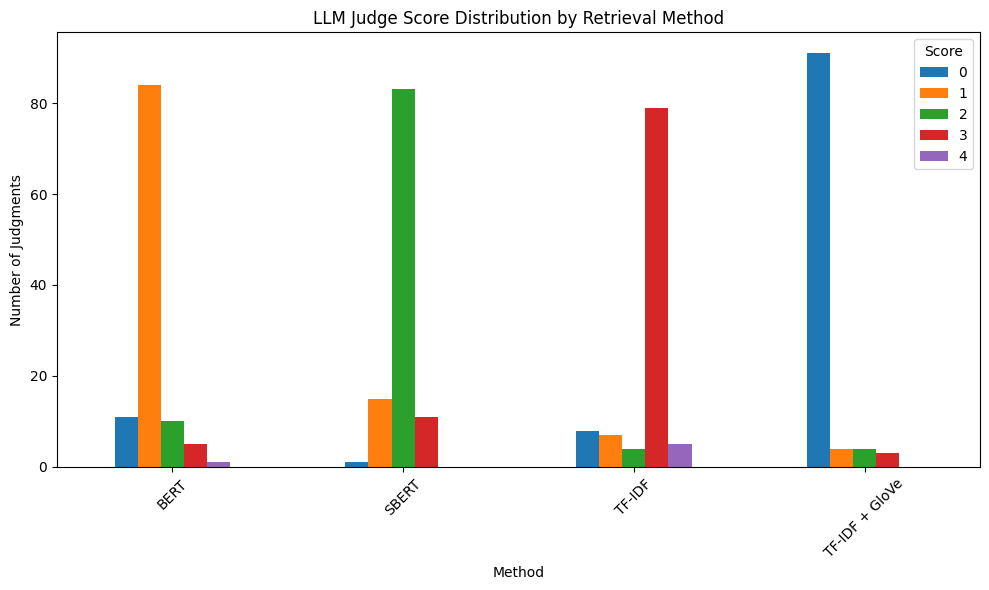

In [343]:
import pandas as pd
import matplotlib.pyplot as plt

#data = data.set_index('Method')

data.plot(
    kind='bar',
    stacked=False,
    figsize=(10, 6)
)

plt.xlabel("Method")
plt.ylabel("Number of Judgments")
plt.title("LLM Judge Score Distribution by Retrieval Method")
plt.legend(title="Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Trying to analyze the frtequency of odering of the ranks. 

In [323]:
new_scoring = new_scoring.drop_duplicates()

In [324]:
rankings = (
    new_scoring
    .sort_values(['Query', 'Rank', 'Score'], ascending=[True, True, False])
    .groupby(['Query', 'Rank'])['Letter Rank']
    .apply(lambda x: ''.join(x))
    .reset_index(name='Ordering')
)

rankings

,Query,Rank,Ordering
0,Psalms that move from lament and despair to p...,1,DDCCBBAA
1,Attend to my supplication,4,DDCCBBAA
2,"Be thou exalted, O bridegroom, like unto Abrah...",1,BCDA
3,"Be thou exalted, O bridegroom, like unto Abrah...",2,CABD
4,Belief,2,BA
...,...,...,...
106,“Psalms that express deep lament and trust in ...,1,DDCBBCAA
107,“Psalms that express deep lament and trust in ...,2,DCBA
108,“Psalms that express deep lament and trust in ...,4,DDCCBBBCAA
109,“Which psalms use parallelism heavily to empha...,3,ABCD


In [325]:
# Keeping only the first set of scores for each query and rank set. 
new_scoring = (
    new_scoring
    .drop_duplicates(
        subset=['Query', 'Rank', 'Method'],
        keep='first'
    )
)
# new_scoring

In [326]:
group_sizes = (
    new_scoring
    .groupby(['Query', 'Rank'])
    .size()
    .reset_index(name='Count')
)

group_sizes['Count'].value_counts()

Count
4    101
2      7
3      3
Name: count, dtype: int64

In [327]:
# Create a single ranking string for each (Query, Rank) pair.
# Example:
#   C (score=3), B (score=2), A (score=1), D (score=0)
# becomes the ordering "CBAD".
rankings = (
    new_scoring
    .sort_values(['Query', 'Rank', 'Score'], ascending=[True, True, False])
    .groupby(['Query', 'Rank'])['Letter Rank']
    .apply(lambda x: ''.join(x))
    .reset_index(name='Ordering')
)

rankings

,Query,Rank,Ordering
0,Psalms that move from lament and despair to p...,1,DCBA
1,Attend to my supplication,4,DCBA
2,"Be thou exalted, O bridegroom, like unto Abrah...",1,BCDA
3,"Be thou exalted, O bridegroom, like unto Abrah...",2,CABD
4,Belief,2,BA
...,...,...,...
106,“Psalms that express deep lament and trust in ...,1,DCBA
107,“Psalms that express deep lament and trust in ...,2,DCBA
108,“Psalms that express deep lament and trust in ...,4,DCBA
109,“Which psalms use parallelism heavily to empha...,3,ABCD


In [328]:
rankings['Ordering'].unique()

<ArrowStringArray>
['DCBA', 'BCDA', 'CABD',   'BA',  'BCA', 'DBCA', 'BCEA', 'ECBA', 'DABC',
 'DCAB', 'BDCA', 'ABCD', 'BCAD', 'CDBA', 'CBDA',  'CBA', 'CBAD', 'EDBA']
Length: 18, dtype: str